In [24]:
!pip install tensorflow
!pip install statsmodels
!pip install openpyxl
!pip install keras --upgrade

## 1. Data Loading & Preprocessing

In [25]:
import warnings, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, classification_report,
                             confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller


In [26]:
raw_df = pd.read_excel(r'Online Retail.xlsx')
print(f"Raw dataset shape: {raw_df.shape}")
raw_df.head()

Raw dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [27]:
print("Data types and non-null counts:")
print(raw_df.info())
print("\n--- Descriptive Statistics ---")
raw_df.describe()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

--- Descriptive Statistics ---


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [28]:
print(f"Missing values:\n{raw_df.isnull().sum()}\n")

# Drop rows where CustomerID is missing
df = raw_df.dropna(subset=['CustomerID']).copy()
print(f"After dropping missing CustomerID: {df.shape}")

# Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancelled orders: {df.shape}")

# Remove rows with negative quantity or unit price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"After removing non-positive Quantity/Price: {df.shape}")

#Winsorizing unit price
Q1 = df["UnitPrice"].quantile(0.25)
Q3 = df["UnitPrice"].quantile(0.75)
IQR_val = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR_val
upper_bound = Q3 + 1.5 * IQR_val

df["UnitPrice"] = df["UnitPrice"].clip(lower=lower_bound, upper=upper_bound)

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert CustomerID to int
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"\nCleaned dataset shape: {df.shape}")
df.head()

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

After dropping missing CustomerID: (406829, 8)
After removing cancelled orders: (397924, 8)
After removing non-positive Quantity/Price: (397884, 8)

Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [29]:
# Reference date = day after the last invoice in the dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency: {reference_date}")

rfm = df.groupby('CustomerID').agg(
    Recency     = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency   = ('InvoiceNo',  'nunique'),
    Monetary    = ('TotalPrice', 'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
rfm.describe()

Reference date for Recency: 2011-12-10 12:50:00
RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,1950.235308
std,1721.808492,100.014169,7.697998,8644.014086
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,291.275000
50%,15299.500000,51.000000,2.000000,640.840000
75%,16778.750000,142.000000,5.000000,1581.770000
max,18287.000000,374.000000,209.000000,274688.420000


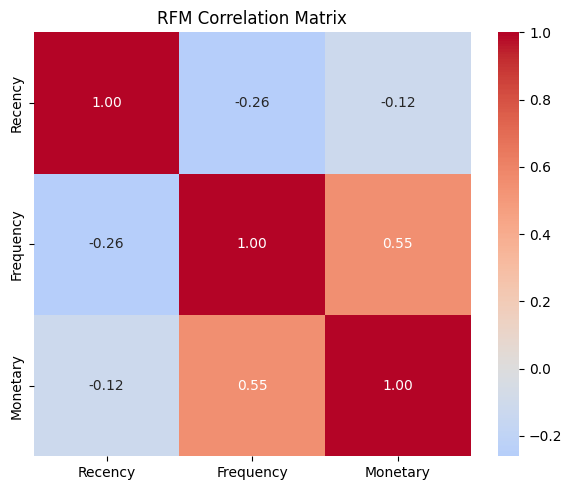


INTERPRETATION:
• Frequency and Monetary are strongly positively correlated — customers who purchase more
  often also spend more in total (expected).



In [30]:
# Recency, Frequency, Monetary Correlation
fig, ax = plt.subplots(figsize=(6, 5))
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('RFM Correlation Matrix')
plt.tight_layout()
plt.show()

print("""
INTERPRETATION:
• Frequency and Monetary are strongly positively correlated — customers who purchase more
  often also spend more in total (expected).
""")

In [31]:
# Log-transform to reduce skewness
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Standard scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Scaled RFM statistics:")
rfm_scaled_df.describe().round(2)

Scaled RFM statistics:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-3.91
25%,-0.66,-0.96,-0.67
50%,0.09,-0.36,-0.05
75%,0.84,0.65,0.66
max,1.56,5.86,4.71


In [32]:
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

In [33]:
RECENCY_THRESHOLD    = 90    # 90 days
FREQUENCY_THRESHOLD  = 3     # 3 unique orders
MONETARY_THRESHOLD   = 100   # total spend

rfm['IsChurned'] = (
    (rfm['Recency'] > RECENCY_THRESHOLD) |
    ((rfm['Frequency'] <= FREQUENCY_THRESHOLD) & (rfm['Monetary'] <= MONETARY_THRESHOLD))
).astype(int)

print(f"Churn distribution:\n{rfm['IsChurned'].value_counts()}")
print(f"\nChurn rate: {rfm['IsChurned'].mean():.2%}")

Churn distribution:
IsChurned
0    2826
1    1512
Name: count, dtype: int64

Churn rate: 34.85%


In [34]:
# Feature engineering
cust_features = df.groupby('CustomerID').apply(lambda g: pd.Series({

    # Average basket size (items per order)
    'AvgBasketSize': g.groupby('InvoiceNo')['Quantity'].sum().mean(),

    # Number of distinct products ever purchased
    'UniqueProducts': g['StockCode'].nunique(),

    # Average unit price
    'AvgUnitPrice': g['UnitPrice'].mean(),

    # Total quantity purchased
    'TotalQuantity': g['Quantity'].sum(),

    # Number of distinct calendar months with at least one purchase
    'NumActiveMonths': g['InvoiceDate'].dt.to_period('M').nunique()
})).reset_index()

print(f"Behavioural feature table shape: {cust_features.shape}")
cust_features.head()


Behavioural feature table shape: (4338, 6)


/tmp/ipykernel_266/4114193363.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cust_features = df.groupby('CustomerID').apply(lambda g: pd.Series({


,CustomerID,AvgBasketSize,UniqueProducts,AvgUnitPrice,TotalQuantity,NumActiveMonths
0,12346,74215.000000,1.0,1.040000,74215.0,1.0
1,12347,351.142857,103.0,2.498132,2458.0,7.0
2,12348,585.250000,22.0,1.571290,2341.0,4.0
3,12349,631.000000,73.0,3.441781,631.0,1.0
4,12350,197.000000,17.0,1.929412,197.0,1.0


In [40]:
clf_df = rfm[['CustomerID', 'IsChurned']].merge(cust_features, on='CustomerID', how='inner')

feature_cols = ['AvgBasketSize', 'UniqueProducts',
                'AvgUnitPrice', 'TotalQuantity', 'NumActiveMonths']


# Manually resampling dataset to have a churn rate of 45.76% during the split exactly like it is on R
target_rate = 0.4576

data = clf_df.copy()

churn = data[data["IsChurned"] == 1]
active = data[data["IsChurned"] == 0]

N = len(data)

target_churn = int(round(N * target_rate))
target_active = N - target_churn

churn_sample = churn.sample(n=target_churn, replace=True, random_state=42)
active_sample = active.sample(n=target_active, replace=True, random_state=None)

balanced = pd.concat([churn_sample, active_sample]).sample(frac=1, random_state=42)

X = balanced[feature_cols].copy()
y = balanced["IsChurned"]

for col in ['AvgBasketSize', 'UniqueProducts', 'TotalQuantity']:
    X[col] = np.log1p(X[col])

# Standard scaling
scaler_clf = StandardScaler()
X_scaled = scaler_clf.fit_transform(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate : {y_test.mean():.2%}")


Train churn rate: 45.76%
Test churn rate : 45.74%


In [41]:
from keras import regularizers
from keras.layers import BatchNormalization
from sklearn.utils import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [42]:
tf.random.set_seed(42)

cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
CHURN_BOOST = 2.0 # Heavier weights to predict churned customers more accurately
class_weights = {0: cw[0], 1: cw[1] * CHURN_BOOST}
print(f"Class weights: {class_weights}")

def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_weight = alpha_t * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss_fn

nn_model = Sequential([
    Dense(128, activation='gelu', input_shape=(X_train.shape[1],),
          kernel_regularizer=regularizers.l2(3e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='gelu',
          kernel_regularizer=regularizers.l2(3e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='gelu'),
    Dropout(0.2),

    Dense(16, activation='gelu'),

    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

nn_model.summary()

# ── 4. Callbacks ──────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_auc', patience=20,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                      patience=7, min_lr=1e-6, mode='max', verbose=1)
]

# ── 5. Train ──────────────────────────────────────────────────────────────────
history = nn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Class weights: {0: np.float64(0.9218916046758767), 1: np.float64(2.1851385390428213)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6376 - auc: 0.6913 - loss: 0.1674 - precision: 0.5967 - recall: 0.6081 - val_accuracy: 0.6556 - val_auc: 0.8152 - val_loss: 0.1028 - val_precision: 0.5886 - val_recall: 0.9522 - learning_rate: 3.0000e-04
Epoch 2/150
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6477 - auc: 0.7285 - loss: 0.1359 - precision: 0.5768 - recall: 0.8244 - val_accuracy: 0.6455 - val_auc: 0.8126 - val_loss: 0.0966 - val_precision: 0.5790 - val_recall: 0.9731 - learning_rate: 3.0000e-04
Epoch 3/150
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6358 - auc: 0.7437 - loss: 0.1268 - precision: 0.5624 - recall: 0.8699 - val_accuracy: 0.6513 - val_auc: 0.8135 - val_loss: 0.0915 - val_precision: 0.5844 - val_recall: 0.9612 - learning_rate: 3.0000e-04
Epoch 4/150
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6365 - auc: 0.7482 - loss: 0.1246 - precision: 0.5617 - recall: 0.8859 - val_accuracy: 0.6527 - val_auc: 0.8139 - val_loss: 0.0

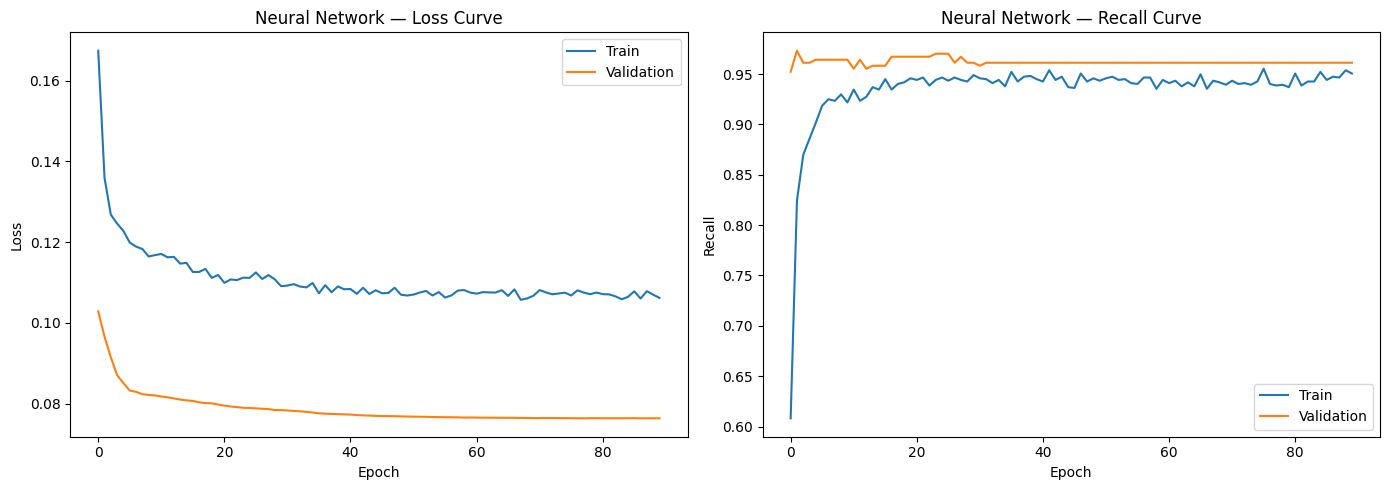

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Neural Network — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['recall'], label='Train')
axes[1].plot(history.history['val_recall'], label='Validation')
axes[1].set_title('Neural Network — Recall Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

In [44]:
y_pred_nn_prob = nn_model.predict(X_test).ravel()
y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred_nn, target_names=['Active','Churned']))

nn_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn),
    'Recall':    recall_score(y_test, y_pred_nn),
    'F1-Score':  f1_score(y_test, y_pred_nn),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_nn_prob)
}

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

      Active       0.91      0.36      0.52       471
     Churned       0.56      0.96      0.71       397

    accuracy                           0.63       868
   macro avg       0.74      0.66      0.61       868
weighted avg       0.75      0.63      0.60       868



In [46]:
nn_metrics

{'Accuracy': 0.6336405529953917,
 'Precision': 0.5578330893118595,
 'Recall': 0.9596977329974811,
 'F1-Score': 0.7055555555555556,
 'ROC-AUC': np.float64(0.8183563563242364)}

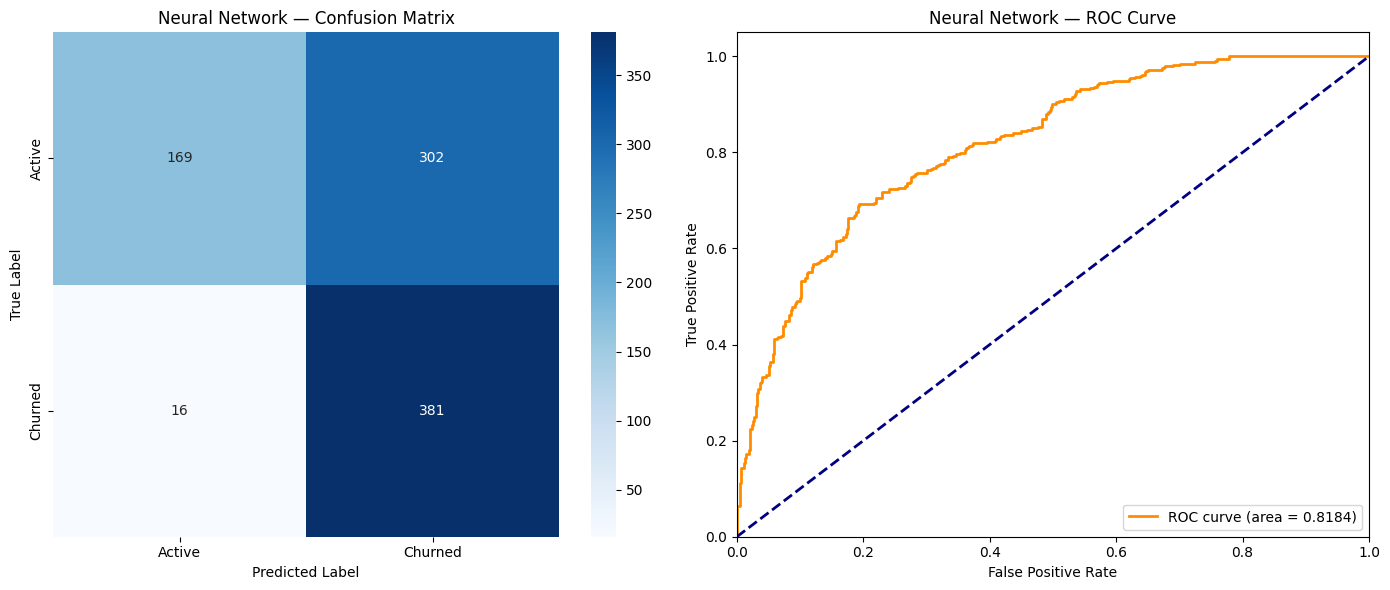

In [45]:
cm = confusion_matrix(y_test, y_pred_nn)
fpr, tpr, _ = roc_curve(y_test, y_pred_nn_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Neural Network — Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')
ax[0].set_xticklabels(['Active', 'Churned'])
ax[0].set_yticklabels(['Active', 'Churned'])

# ROC Curve
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Neural Network — ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()